# Why cross-model agreement flags logic errors: a consensus mechanism audit

This notebook is a runnable walkthrough of **`eval.py`**, the evaluation from the NL→FOL (autoformalization) project that asks **why a label-free,
cross-model agreement score predicts whether a FOL translation is faithful to its sentence**, with no gold formula.

**Setup (dataset E).** 700 English sentences, each translated to first-order logic by LLMs from 8 vendor families (plus gold/CCG rows that are never peers).
For every sentence, every pair of parseable outputs was checked with **z3 equivalence modulo vocabulary (eqmv)**. The result is a *label-free* pairwise matrix.
A candidate's **consensus score** is `c = 1 − (#cross-family peer outputs equivalent to it) / (#cross-family peer outputs)`.
A high `c` means other models disagree, so the candidate is predicted to be an ERROR.

**What `eval.py` does:**
1. computes the pairwise eqmv matrix (z3, CPU-heavy; **precomputed** here, loaded from the data file),
2. `part_a.run()`: reads consensus quantities per row (`c_score_align`, aligner-free `c_score_exact`, and binary endorsement rules `END_MAJ / END_PLUR / END_FAM2 / END_FAMMAJ`),
   decomposes binary consensus exactly as **AUROC_b = 1 − (e + d)/2**, where
   *e* = P(endorsed | ERROR) is error endorsement and *d* = P(not endorsed | CORRECT) is correct divergence,
   compares graded and binary consensus, and runs the mechanism tests (M1/M2 GEE, NET Δ(e+d) by sentence length),
3. `figures(A)`: draws the four paper figures,
4. `build_eval_out()`: writes `eval_out.json`.

**In this demo:** steps 2–3 run on a **subset** (100 of the 292 labelled R_AB sentences, 25 per stratum), and the
code of `consensus_mx.py`, `stats.py`, `mechanism.py` and `part_a.py` is copied unchanged. Then `eval.py`'s own `figures()` function draws the paper figures
from the aggregates of the full 700-sentence run, which ship in the same data file. The z3 matrix, M4 family pools and SCATTER need the full run and are not recomputed here.
CPU only, no LLM calls, $0.

**Full-run headline results (R_AB, 2,672 scorable rows):** graded `c_score_align` AUROC **0.784** vs binary majority END_MAJ **0.669**
(Δ +0.114 [0.091, 0.140]). END_MAJ has e = 0.124 and d = 0.537. For binary consensus, Δ(e+d) between the longest and shortest word terciles is +0.356 [0.198, 0.493], so binary consensus
**degrades with sentence length**, driven by *d* (correct translations of long sentences diverge legitimately).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

## Imports

This is the original `eval.py` import block plus the imports of the `src/` modules it calls (`stats.py`, `consensus_mx.py`, `mechanism.py`).
Two notebook-context changes:
* `eval.py` re-executes itself with `PYTHONHASHSEED=0` because z3 eqmv hashes strings. This notebook makes no eqmv calls (the matrix is precomputed), so the re-exec is dropped.
* The `logs/eval.log` file sink and the 20 GB `RLIMIT_AS` cap are left out (kept as comments). They are for the batch script only.

In [2]:
from __future__ import annotations

import argparse
import json
import os
import re
import subprocess
import sys
import time
import warnings
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib
import matplotlib.pyplot as plt

ROOT = Path(".").resolve()
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(ROOT / "logs" / "eval.log", rotation="30 MB", level="DEBUG")   # original file sink (script only)
# resource.setrlimit(resource.RLIMIT_AS, (20 * 1024 ** 3, 20 * 1024 ** 3))  # original: 29 GB container; fail fast instead of OOM


def jdump(p: Path, o):
    p.write_text(json.dumps(o, indent=1, default=lambda x: x.item() if hasattr(x, "item") else str(x)))

## Load the demo data

`mini_demo_data.json` holds:
* `matrix`: the **label-free** z3 eqmv matrix (nodes = distinct canonical formulas; `pairs = [i, j, equivalent?, reason, secs]`) for 100 R_AB sentences, in the same format as the artifact's `pairwise_classes_E.jsonl`,
* `rows`: every row of those sentences (candidate FOL, vendor family, stratum, words, n_conditions, label, frozen `c_score_align`), joined as `src/frame.py::build_frame` does,
* `full_run`: aggregates of the full 700-sentence run (`results/part_a.json` subset, `tables/*.csv`, `eval_out.json` metrics) used by `figures()` and for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-3/evaluation-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"{len(data['matrix'])} sentences with a precomputed eqmv matrix, {len(data['rows'])} rows")
print(f"{sum(len(m['pairs']) for m in data['matrix'])} z3 pairs; z3 {data['matrix'][0]['z3_version']}, eqmv timeout {data['matrix'][0]['eqmv_ms']} ms")

100 sentences with a precomputed eqmv matrix, 1244 rows
3743 z3 pairs; z3 5.1.0, eqmv timeout 3000 ms


## Configuration

| parameter | demo value | original (`eval.py --stage all`) |
|---|---|---|
| `N_SENTENCES` | number of R_AB sentences analysed (ordered so every stratum is represented) | all 292 R_AB sentences (100 in this data file) |
| `B_BOOT` | sentence-cluster bootstrap replicates (CIs and the NET AME refits) | 2000 |
| `SEED` | bootstrap seed | 0 |
| `MIN_ROWS`, `MIN_SENT` | minimum cell size for a bootstrap CI (smaller cells stay descriptive) | 30, 10 (unchanged) |

In [5]:
N_SENTENCES = 100   # original: all 292 R_AB sentences (this data file holds 100)
B_BOOT = 2000         # original: 2000
SEED = 0             # original: 0
MIN_ROWS, MIN_SENT = 30, 10   # original (prereg min_cell)

## Statistics helpers (`src/stats.py`, unchanged)

`auc` is a tie-aware Mann–Whitney AUROC (identical to sklearn). `strat_auc` is a within-stratum pair AUROC. `SentBoot` is a sentence-cluster bootstrap expressed as multiplicity weights,
so each replicate's AUROC / e / d is a weighted sum. `WAuc` is the weighted AUROC.

In [6]:
def auc(y, s) -> float:
    '''Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score).'''
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    '''Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified').'''
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class WAuc:
    '''AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once.'''

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class SentBoot:
    '''Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement).'''

    def __init__(self, sids, b: int = 2000, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        '''(B, n_rows[mask]) weight matrix.'''
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]

## Reading the label-free matrix (`src/consensus_mx.py`, unchanged)

`SentenceMatrix` indexes one sentence's pairwise eqmv results. `row_consensus` computes, for one candidate row, everything the audit needs from its
**cross-family** peers (LLM rows from *other* vendor families):
* `c_re` is the graded consensus score, which re-derives the frozen `c_score_align`. `c_exact` counts only `reason == 'exact'` agreements, so it needs no aligner.
* `end_maj` is endorsed by a strict majority of peer rows. `end_fam2` is endorsed by ≥2 other families. `end_fammaj` is endorsed by a majority of families, one vote each.
  `end_plur` means the candidate is equivalent to the unique largest peer class.
* `fam_stats` gives per-family [rows, equivalent, exactly equal] counts.

UNKNOWN solver results count as *not equivalent*.

In [7]:
class SentenceMatrix:
    '''One sentence's matrix record (pairwise_classes / pair_matrix line) with O(1) node-pair lookups.'''

    def __init__(self, rec: dict):
        self.rec = rec
        self.sid = rec["sentence_id"]
        self.nodes = rec["nodes"]
        self.n = len(self.nodes)
        self.eq = {}
        self.reason = {}
        self.secs = {}
        for i, j, e, rs, s in rec["pairs"]:
            self.eq[(i, j)] = self.eq[(j, i)] = e
            self.reason[(i, j)] = self.reason[(j, i)] = rs
            self.secs[(i, j)] = self.secs[(j, i)] = s
        self.row_node = {}
        self.row_meta = {}
        for nd in self.nodes:
            for r in nd["rows"]:
                self.row_node[r["row_key"]] = nd["node_id"]
                self.row_meta[r["row_key"]] = r
        self.adj = defaultdict(set)
        for (i, j), e in self.eq.items():
            if e is True:
                self.adj[i].add(j)
        self.comp = self._components()

    def is_eq(self, i: int, j: int) -> bool:
        return True if i == j else self.eq.get((i, j)) is True

    def is_exact(self, i: int, j: int) -> bool:
        return True if i == j else (self.eq.get((i, j)) is True and self.reason.get((i, j)) == "exact")

    def _components(self) -> list[int]:
        comp = [-1] * self.n
        c = 0
        for s in range(self.n):
            if comp[s] >= 0:
                continue
            stack = [s]
            comp[s] = c
            while stack:
                u = stack.pop()
                for v in self.adj[u]:
                    if comp[v] < 0:
                        comp[v] = c
                        stack.append(v)
            c += 1
        return comp

    def components(self) -> list[list[int]]:
        by = defaultdict(list)
        for i, c in enumerate(self.comp):
            by[c].append(i)
        return [by[c] for c in sorted(by)]

    def cliques(self) -> list[list[int]]:
        '''Greedy clique partition: take the max-degree remaining node and its pairwise-True common neighbours.'''
        left = set(range(self.n))
        out = []
        while left:
            u = max(sorted(left), key=lambda x: len(self.adj[x] & left))
            cl = [u]
            for v in sorted(self.adj[u] & left, key=lambda x: -len(self.adj[x] & left)):
                if all(self.is_eq(v, w) for w in cl):
                    cl.append(v)
            out.append(sorted(cl))
            left -= set(cl)
        return out

    def nontransitive(self) -> tuple[int, int]:
        '''(#open wedges a~b, b~c, a!~c ; #wedges a~b, b~c) over unordered node triples, counted per centre b.'''
        n_open = n_w = 0
        for b in range(self.n):
            nb = sorted(self.adj[b])
            for a, c in combinations(nb, 2):
                n_w += 1
                if not self.is_eq(a, c):
                    n_open += 1
        return n_open, n_w


def row_consensus(sm: SentenceMatrix, row_key: str, family_key: str = "family") -> dict | None:
    '''All consensus readouts of one candidate row (None if unparseable). family_key='family' (vendor, primary) or
    'family_field' (slot-level sensitivity).'''
    if row_key not in sm.row_node:
        return None
    ci = sm.row_node[row_key]
    me = sm.row_meta[row_key]
    fam = me[family_key]
    P = [(rk, m) for rk, m in sm.row_meta.items() if m["is_peer"] and m[family_key] != fam and rk != row_key]
    npc = len(P)
    fam_stats = defaultdict(lambda: [0, 0, 0])  # family -> [n_rows, n_eq, n_eq_exact]
    n_eq = n_ex = 0
    for rk, m in P:
        pj = sm.row_node[rk]
        e = sm.is_eq(ci, pj)
        x = sm.is_exact(ci, pj)
        n_eq += e
        n_ex += x
        fs = fam_stats[m[family_key]]
        fs[0] += 1
        fs[1] += e
        fs[2] += x
    out = {"npc": npc, "n_eq": n_eq, "n_eq_exact": n_ex, "node": ci, "comp": sm.comp[ci],
           "fam_stats": {k: list(v) for k, v in fam_stats.items()}}
    if npc < 2:
        out.update(c_re=None, c_exact=None, end_maj=None, end_plur=None, end_fam2=None, end_fammaj=None)
        return out
    out["c_re"] = 1 - n_eq / npc
    out["c_exact"] = 1 - n_ex / npc
    out["end_maj"] = bool(n_eq > npc / 2)
    fams_endorse = [f for f, v in fam_stats.items() if v[1] > 0]
    out["end_fam2"] = bool(len(fams_endorse) >= 2)
    out["end_fammaj"] = bool(len(fams_endorse) > len(fam_stats) / 2)
    out["n_fam_avail"] = len(fam_stats)
    out["n_fam_endorse"] = len(fams_endorse)
    # END_PLUR: components of the True graph induced on the peer nodes; class size = peer rows
    pnodes = sorted({sm.row_node[rk] for rk, _ in P})
    rows_per_node = defaultdict(int)
    for rk, _ in P:
        rows_per_node[sm.row_node[rk]] += 1
    comp = {}
    c = 0
    for s in pnodes:
        if s in comp:
            continue
        comp[s] = c
        stack = [s]
        while stack:
            u = stack.pop()
            for v in sm.adj[u]:
                if v in rows_per_node and v not in comp:
                    comp[v] = c
                    stack.append(v)
        c += 1
    size = defaultdict(int)
    for nd, k in rows_per_node.items():
        size[comp[nd]] += k
    best = max(size.values())
    tops = [k for k, v in size.items() if v == best]
    if len(tops) > 1:
        out["end_plur"] = False
    else:
        cls = [nd for nd in pnodes if comp[nd] == tops[0]]
        out["end_plur"] = bool(any(sm.is_eq(ci, nd) for nd in cls))
    out["plur_top_share"] = best / npc
    return out

## e/d decomposition, cuts and mechanism tests (`src/mechanism.py`, unchanged)

* `ed_decomposition(y, endorsed)` asserts the bookkeeping identity **AUROC_b = 1 − (e + d)/2** for a binary endorsement rule.
* `cell_stats` / `run_cuts` compute e, d, AUROC_b and the graded AUROC per cell (stratum, words tercile, n_conditions bin, …) with sentence-cluster CIs.
* `graded_trace` gives the (e_t, d_t) pair at every threshold of the graded score. The three named points are "any peer agrees", "majority" and "all peers agree".
* `mechanism_M1_M2` fits GEEs. **M1**: do ERROR rows get endorsed less often as `n_conditions` grows? **M2**: do CORRECT rows diverge more as `words` grows?
* `net_test` computes **Δ(e+d)** between the longest and shortest words tercile. If it is > 0, binary consensus gets *worse* on long sentences.

In [8]:
RULES = ["MAJ", "PLUR", "FAM2", "FAMMAJ", "MAJ_EXACT"]
# MIN_ROWS, MIN_SENT = 30, 10  -> set in the config cell


# =================================================================================================== identity
def ed_decomposition(y, endorsed) -> dict:
    '''y: 1 = ERROR, 0 = CORRECT; endorsed: 1 = the cross-family peer rule endorses the candidate.
    Returns e = P(endorsed | ERROR) (error-endorsement), d = P(not endorsed | CORRECT) (correct-divergence) and
    AUROC_b of b = 1 - endorsed, asserting the bookkeeping identity AUROC_b = 1 - (e + d)/2 (balanced accuracy).'''
    y = np.asarray(y, int)
    en = np.asarray(endorsed, int)
    e = float(en[y == 1].mean())
    d = float((1 - en[y == 0]).mean())
    a = auc(y, 1 - en)
    assert abs(a - (1 - (e + d) / 2)) < 1e-12, (a, e, d)
    return {"n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()), "e": e, "d": d, "auroc_b": a}


# =================================================================================================== bins
def make_bins(df: pd.DataFrame, cut: dict) -> pd.DataFrame:
    q1, q2 = cut["words_tercile_cuts"]
    df = df.copy()
    df["words_t"] = np.where(df.words <= q1, "T1", np.where(df.words <= q2, "T2", "T3"))
    nc = df.n_conditions.fillna(-1).astype(int)
    df["ncond_bin"] = np.where(nc <= 1, "0-1", np.where(nc == 2, "2", np.where(nc == 3, "3", "4+")))
    et = df.exception_type.fillna("none").astype(str)
    keep = set(cut["exception_types_kept"])
    df["exc_bin"] = np.where(et == "none", "none", np.where(et.isin(keep), et, "other_exc"))
    df["long"] = df.stratum.isin(["L25", "L20", "EXC"])
    return df


def prereg_cuts(rab: pd.DataFrame) -> dict:
    sent = rab.drop_duplicates("sentence_id")
    q1, q2 = np.quantile(sent.words.values, [1 / 3, 2 / 3])
    et = rab.exception_type.fillna("none").astype(str)
    cnt = Counter(et[et != "none"])
    return {"words_tercile_cuts": [float(q1), float(q2)], "words_tercile_rule": "T1: words<=q1, T2: q1<words<=q2, T3: >q2; "
            "cut points = 1/3, 2/3 quantiles of R_AB SENTENCE words (np.quantile, linear)",
            "n_conditions_bins": ["0-1", "2", "3", "4+"], "exception_types_kept": sorted(k for k, v in cnt.items() if v >= 30),
            "exception_type_counts_R_AB_rows": dict(cnt)}


# =================================================================================================== cuts
def cell_stats(sub: pd.DataFrame, ycol: str, rule_cols: dict, boot: SentBoot, W_all: np.ndarray, pos: np.ndarray,
               score_col: str = "c_frozen") -> list[dict]:
    '''e, d, AUROC_b per rule and AUROC(score) for one cell, with sentence-cluster bootstrap CIs.'''
    y = sub[ycol].values.astype(int)
    n1, n0 = int(y.sum()), int((1 - y).sum())
    nsent = sub.sentence_id.nunique()
    W = W_all[:, pos]
    ok_e = n1 >= MIN_ROWS and nsent >= MIN_SENT
    ok_d = n0 >= MIN_ROWS and nsent >= MIN_SENT
    out = []
    a_c = auc(y, sub[score_col].values) if n1 and n0 else float("nan")
    a_c_ci = [None, None]
    if ok_e and ok_d:
        wa = WAuc(y, sub[score_col].values)
        a_c_ci = ci([wa(W[b]) for b in range(W.shape[0])])
    for rule, col in rule_cols.items():
        en = sub[col].values.astype(float)
        if np.isnan(en).any():
            m = ~np.isnan(en)
            logger.warning(f"rule {rule}: {int((~m).sum())} rows without a value dropped in cell")
        e = float(en[y == 1].mean()) if n1 else float("nan")
        d = float((1 - en[y == 0]).mean()) if n0 else float("nan")
        ab = 1 - (e + d) / 2 if n1 and n0 else float("nan")
        if n1 and n0:
            assert abs(ab - auc(y, 1 - en)) < 1e-12
        rec = {"rule": rule, "n_err": n1, "n_cor": n0, "n_sent": nsent, "e": e, "d": d, "auroc_b": ab, "auroc_c": a_c,
               "auroc_c_ci": a_c_ci, "inference": "tested" if (ok_e and ok_d) else ("partial" if (ok_e or ok_d) else "descriptive")}
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W @ (en * y)) / (W @ y) if ok_e else None
            db = (W @ ((1 - en) * (1 - y))) / (W @ (1 - y)) if ok_d else None
        rec["e_ci"] = ci(eb) if eb is not None else [None, None]
        rec["d_ci"] = ci(db) if db is not None else [None, None]
        rec["auroc_b_ci"] = ci(1 - (eb + db) / 2) if (eb is not None and db is not None) else [None, None]
        out.append(rec)
    return out


def run_cuts(P: pd.DataFrame, boot: SentBoot, regimes: dict, rule_cols: dict) -> pd.DataFrame:
    '''P = consensus-scorable population frame (aligned with boot rows). regimes = {name: (mask, ycol)}.'''
    W_all = boot.W()
    rows = []
    dims = {"ALL": lambda d: pd.Series("ALL", index=d.index), "stratum": lambda d: d.stratum,
            "long_pool": lambda d: pd.Series(np.where(d.long, "L25+L20+EXC", None), index=d.index),
            "words_tercile": lambda d: d.words_t, "ncond_bin": lambda d: d.ncond_bin, "exception_type": lambda d: d.exc_bin,
            "label_tier": lambda d: d.label_tier}
    for rname, (mask, ycol) in regimes.items():
        sub0 = P[mask]
        pos0 = np.where(mask)[0]
        for dim, fn in dims.items():
            lab = fn(sub0)
            for val in sorted(v for v in lab.dropna().unique()):
                m = (lab == val).values
                for rec in cell_stats(sub0[m], ycol, rule_cols, boot, W_all, pos0[m]):
                    rows.append({"regime": rname, "dim": dim, "cell": val, **rec})
    return pd.DataFrame(rows)


# =================================================================================================== graded trace
def graded_trace(y, c) -> dict:
    '''(e_t, d_t) at every distinct threshold t of the graded score (flag = c >= t); the ROC = (d_t, 1 - e_t).
    Asserts the trapezoid area equals the tie-aware AUROC to 1e-9.'''
    y = np.asarray(y, int)
    c = np.asarray(c, float)
    ts = np.unique(c)
    pts = [(0.0, 0.0)]
    tr = []
    for t in ts[::-1]:
        fl = c >= t
        tpr = fl[y == 1].mean()
        fpr = fl[y == 0].mean()
        tr.append({"t": float(t), "e_t": float(1 - tpr), "d_t": float(fpr)})
        pts.append((fpr, tpr))
    pts.append((1.0, 1.0))
    xs, ys = zip(*pts)
    area = float(np.trapezoid(ys, xs))
    a = auc(y, c)
    assert abs(area - a) < 1e-9, (area, a)
    named = {}
    for nm, en in (("any_peer_agrees (c<1)", c < 1), ("majority END_MAJ (c<0.5)", c < 0.5), ("all_peers_agree (c==0)", c == 0)):
        named[nm] = {"e": float(en[y == 1].mean()), "d": float((~en)[y == 0].mean()),
                     "auroc_b": float(1 - (en[y == 1].mean() + (~en)[y == 0].mean()) / 2)}
    return {"trace": tr, "trapezoid_area": area, "auroc": a, "named_points": named}


# =================================================================================================== GEE
def gee_fit(data: pd.DataFrame, formula: str, groups: str = "sentence_id") -> dict:
    '''Binomial-logit GEE, exchangeable working correlation, robust SE; falls back to Independence.'''
    out = {"formula": formula, "n": len(data), "n_clusters": int(data[groups].nunique())}
    for cs_name, cs in (("Exchangeable", sm.cov_struct.Exchangeable()), ("Independence", sm.cov_struct.Independence())):
        try:
            with warnings.catch_warnings(record=True) as wl:
                warnings.simplefilter("always")
                m = smf.gee(formula, groups, data=data, family=sm.families.Binomial(), cov_struct=cs)
                r = m.fit(maxiter=200)
            conv_warn = [str(w.message)[:120] for w in wl if "converge" in str(w.message).lower() or "singular" in str(w.message).lower()]
            ciq = r.conf_int()
            if not np.all(np.isfinite(r.bse.values)):
                raise np.linalg.LinAlgError("non-finite SE")
            if conv_warn and cs_name == "Exchangeable":
                raise RuntimeError("; ".join(conv_warn))
            out.update({"cov_struct": cs_name, "warnings": conv_warn,
                        "coef": {k: {"b": float(r.params[k]), "se": float(r.bse[k]), "ci": [float(ciq.loc[k, 0]), float(ciq.loc[k, 1])],
                                     "p": float(r.pvalues[k])} for k in r.params.index}})
            return out
        except (np.linalg.LinAlgError, ValueError, RuntimeError, ZeroDivisionError) as e:  # noqa: PERF203
            logger.warning(f"GEE {cs_name} failed for {formula}: {str(e)[:150]}")
            out[f"fail_{cs_name}"] = str(e)[:200]
    out["coef"] = None
    return out


def vif_table(data: pd.DataFrame, cols: list[str], strat: bool = True) -> dict:
    X = data[cols].astype(float)
    if strat:
        X = pd.concat([X, pd.get_dummies(data.stratum, prefix="st", drop_first=True).astype(float)], axis=1)
    X = sm.add_constant(X)
    return {c: float(variance_inflation_factor(X.values, i)) for i, c in enumerate(X.columns) if c != "const"}


def verdict_slope(coef: dict | None, key: str, want: str) -> str:
    if not coef or key not in coef:
        return "UNTESTABLE"
    lo, hi = coef[key]["ci"]
    if want == "neg":
        return "CONFIRMED" if hi < 0 else ("REFUTED" if lo > 0 else "INCONCLUSIVE")
    return "CONFIRMED" if lo > 0 else ("REFUTED" if hi < 0 else "INCONCLUSIVE")


def zcols(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["zn"] = (d.n_conditions - d.n_conditions.mean()) / d.n_conditions.std()
    d["zw"] = (d.words - d.words.mean()) / d.words.std()
    return d


def mechanism_M1_M2(P: pd.DataFrame, rule_cols: dict) -> dict:
    '''M1: endorsed ~ z(n_conditions) + z(words) + C(stratum) among R_AB ERROR rows (prediction: n_conditions < 0).
    M2: divergent ~ z(words) + z(n_conditions) + C(stratum) among R_AB CORRECT rows (prediction: words > 0).'''
    res = {"M1": {}, "M2": {}}
    ab = P[P.in_RAB]
    for rule, col in rule_cols.items():
        for side, yv, dep, key, want in (("M1", 1, "endorsed", "zn", "neg"), ("M2", 0, "divergent", "zw", "pos")):
            base = ab[ab.y_AB == yv].copy()
            base["endorsed"] = base[col].astype(int)
            base["divergent"] = 1 - base["endorsed"]
            variants = {"primary": (zcols(base), f"{dep} ~ zn + zw + C(stratum)")}
            if rule == "MAJ":
                variants["long_pool_only"] = (zcols(base[base.long]), f"{dep} ~ zn + zw + C(stratum)")
                variants["plus_vendor_family"] = (zcols(base), f"{dep} ~ zn + zw + C(stratum) + C(family_vendor)")
                variants["no_stratum_dummies"] = (zcols(base), f"{dep} ~ zn + zw")
                variants["EXPLORATORY_ncond_only"] = (zcols(base), f"{dep} ~ zn")
                variants["EXPLORATORY_words_only"] = (zcols(base), f"{dep} ~ zw")
                ra = base[base.label_tier == "A"]
                variants["R_A_only"] = (zcols(ra), f"{dep} ~ zn + zw + C(stratum)")
                if side == "M2":
                    for cne in (True, False):
                        sub = base[base.correct_not_equivalent == cne]
                        variants[f"CNE={cne}"] = (zcols(sub), f"{dep} ~ zn + zw + C(stratum)")
            for vn, (d, f) in variants.items():
                g = gee_fit(d, f)
                kk = key if key in (g["coef"] or {}) else ("zw" if key == "zn" else "zn")  # EXPLORATORY single-predictor fits
                g["verdict"] = verdict_slope(g["coef"], kk, want)
                g["verdict_on"] = kk
                g["rate"] = float(d[dep].mean())
                res[side][f"{rule}|{vn}"] = g
    base = zcols(ab)
    res["VIF"] = vif_table(base, ["zn", "zw"])
    res["corr_words_ncond_rows"] = float(np.corrcoef(ab.words, ab.n_conditions)[0, 1])
    # d split by correct_not_equivalent (the hypothesis puts d in the CNE rows)
    cor = ab[ab.y_AB == 0]
    res["M2_d_by_CNE"] = {str(k): {"n": int(len(g)), "d_MAJ": float(1 - g["end_MAJ"].mean())} for k, g in cor.groupby("correct_not_equivalent")}
    return res


# =================================================================================================== NET
def _ame(X: np.ndarray, yv: np.ndarray, w: np.ndarray, j: int) -> float:
    m = LogisticRegression(C=1e6, max_iter=500).fit(X, yv, sample_weight=w)
    p = m.predict_proba(X)[:, 1]
    return float(np.average(m.coef_[0][j] * p * (1 - p), weights=w))


def net_test(P: pd.DataFrame, boot: SentBoot, col: str = "end_MAJ", long_only: bool = False) -> dict:
    '''Delta(e+d) top vs bottom words tercile (and n_conditions 4+ vs 0-1) with cluster-bootstrap CIs, plus the summed
    average marginal effect per SD (AME_e + AME_d) from plain logistic refits in every replicate.'''
    mask = P.in_RAB.values & (P.long.values if long_only else True)
    W = boot.W(mask)
    d = P[mask]
    y = d.y_AB.values.astype(int)
    en = d[col].values.astype(float)
    out = {}
    for nm, lo_m, hi_m in (("words_T3_minus_T1", d.words_t.values == "T1", d.words_t.values == "T3"),
                           ("ncond_4p_minus_01", d.ncond_bin.values == "0-1", d.ncond_bin.values == "4+")):
        def ed(Wm, m):
            with np.errstate(invalid="ignore", divide="ignore"):
                e = (Wm[..., m] @ (en[m] * y[m])) / (Wm[..., m] @ y[m])
                dd = (Wm[..., m] @ ((1 - en[m]) * (1 - y[m]))) / (Wm[..., m] @ (1 - y[m]))
            return e, dd
        one = np.ones(len(d))
        e_lo, d_lo = ed(one, lo_m)
        e_hi, d_hi = ed(one, hi_m)
        eb_lo, db_lo = ed(W, lo_m)
        eb_hi, db_hi = ed(W, hi_m)
        delta = (e_hi + d_hi) - (e_lo + d_lo)
        dB = (eb_hi + db_hi) - (eb_lo + db_lo)
        c = ci(dB)
        verdict = ("IMPROVES_WITH_COMPLEXITY (scatter dominates)" if c[1] is not None and c[1] < 0 else
                   "DEGRADES_WITH_COMPLEXITY (legitimate divergence dominates)" if c[0] is not None and c[0] > 0 else
                   "BALANCED_OR_UNDETERMINED")
        out[nm] = {"delta_e_plus_d": float(delta), "ci": c, "delta_e": float(e_hi - e_lo), "delta_e_ci": ci(eb_hi - eb_lo),
                   "delta_d": float(d_hi - d_lo), "delta_d_ci": ci(db_hi - db_lo), "e_lo": float(e_lo), "d_lo": float(d_lo),
                   "e_hi": float(e_hi), "d_hi": float(d_hi), "n_lo": int(lo_m.sum()), "n_hi": int(hi_m.sum()),
                   "delta_auroc_b": float(-delta / 2), "verdict": verdict,
                   "driver": "e" if abs(e_hi - e_lo) > abs(d_hi - d_lo) else "d"}
    # AME per SD (words and n_conditions), plain logistic with stratum dummies (dropped within the long pool? kept)
    dz = zcols(d)
    X = np.column_stack([dz.zw.values, dz.zn.values, pd.get_dummies(d.stratum, drop_first=True).values.astype(float)])
    err, cor = y == 1, y == 0
    for j, nm in ((0, "words"), (1, "n_conditions")):
        ame_e = _ame(X[err], en[err], np.ones(err.sum()), j)
        ame_d = _ame(X[cor], 1 - en[cor], np.ones(cor.sum()), j)
        bs = []
        for b in range(W.shape[0]):
            w = W[b]
            try:
                bs.append(_ame(X[err], en[err], w[err] + 1e-12, j) + _ame(X[cor], 1 - en[cor], w[cor] + 1e-12, j))
            except ValueError:
                continue
        out[f"AME_sum_per_SD_{nm}"] = {"ame_e": ame_e, "ame_d": ame_d, "sum": ame_e + ame_d, "ci": ci(bs), "n_boot": len(bs)}
    return out

## Analysis frame (`src/frame.py`)

`build_frame()` joins exp 5's `per_item_E` (frozen `c_score_align`), `E_labels` and `E_blind` on `row_key`. The join is precomputed in `data["rows"]`
for the selected sentences. `regime()` is unchanged. It defines **R_AB**: LLM rows with label tier A or B, a CORRECT/ERROR label, and no reading-choice ambiguity.
`y_AB = 1` means ERROR.

In [9]:
def regime(r: dict, which: str) -> int | None:
    '''analyse_E.regime(r, which) with default args (tiers A+B, no CONTESTED, no reading_choice, llm rows only).'''
    if r["system_class"] != "llm" or r.get("reading_choice"):
        return None
    fl = r["final_label"]
    if fl not in ("CORRECT", "ERROR"):
        return None
    if r["label_tier"] not in ("A", "B"):
        return None
    if which == "R_A" and r["label_tier"] != "A":
        return None
    return 1 if fl == "ERROR" else 0


# --- notebook: build_frame() on the demo rows of the first N_SENTENCES sentences (instead of reading exp 5 files)
SEL = set(data["sentence_order"][:N_SENTENCES])
recs = []
for d in data["rows"]:
    if d["sentence_id"] not in SEL:
        continue
    d = dict(d)
    d["y_AB"] = regime(d, "R_AB")
    d["y_A"] = regime(d, "R_A")
    recs.append(d)
df = pd.DataFrame(recs)
print(f"{df.sentence_id.nunique()} sentences, {len(df)} rows; R_AB rows: {int(df.y_AB.notna().sum())} "
      f"({int((df.y_AB == 1).sum())} ERROR / {int((df.y_AB == 0).sum())} CORRECT)")
df[["stratum", "family_vendor", "final_label", "c_frozen", "text", "candidate_fol"]].head(6)

100 sentences, 1244 rows; R_AB rows: 967 (584 ERROR / 383 CORRECT)


,stratum,family_vendor,final_label,c_frozen,text,candidate_fol
0,L20,openai,ERROR,0.777778,A musical composition typically consisting of ...,∀x ((MusicalComposition(x) ∧ TypicallyConsists...
1,L20,meta,CORRECT,0.500000,A musical composition typically consisting of ...,∀x (MusicalComposition(x) ∧ TypicallyConsistsO...
2,L20,meta,ERROR,1.000000,A musical composition typically consisting of ...,∀x (Concerto(x) ↔ (MusicalComposition(x) ∧ Typ...
3,L20,meta,ERROR,1.000000,A musical composition typically consisting of ...,"∀x (MusicalComposition(x) ∧ Typically(x, multi..."
4,L20,qwen,UNPARSEABLE,1.000000,A musical composition typically consisting of ...,∀x (MusicalComposition(x) ∧ (∃n (n > 1 ∧ HasMo...
5,L20,qwen,UNPARSEABLE,1.000000,A musical composition typically consisting of ...,∀x (MusicalComposition(x) ∧ (∃n (n > 1 ∧ HasMo...


## Matrix readouts, gate G2 and non-transitivity (from `part_a.run()`)

For every row, `row_consensus` recomputes the consensus quantities from the **label-free** matrix.
**Gate G2** checks that the recomputed `c_re` reproduces the frozen `c_score_align` from exp 5. The full run had a 0.33% mismatch, explained by `PYTHONHASHSEED` inside eqmv's aligner.
**Non-transitivity** is the share of open wedges (a≡b, b≡c, but a≢c). A high rate means eqmv "classes" are only approximate.

In [10]:
mats = {r["sentence_id"]: r for r in data["matrix"] if r["sentence_id"] in SEL}
sms = {s: SentenceMatrix(r) for s, r in mats.items()}
A = {}
# ---------------- matrix readouts
rc = []
for r in df.itertuples():
    sm_ = sms.get(r.sentence_id)
    x = row_consensus(sm_, r.row_key) if sm_ else None
    xf = row_consensus(sm_, r.row_key, "family_field") if sm_ else None
    d = {"row_key": r.row_key, "matrix_present": sm_ is not None}
    if x:
        d.update({k: x.get(k) for k in ("npc", "n_eq", "n_eq_exact", "node", "comp", "c_re", "c_exact", "end_maj", "end_plur",
                                         "end_fam2", "end_fammaj", "n_fam_avail", "n_fam_endorse", "plur_top_share")})
        d["fam_stats"] = x["fam_stats"]
        d["fam_stats_ff"] = xf["fam_stats"]
    rc.append(d)
df = df.merge(pd.DataFrame(rc), on="row_key", how="left")
# ---------------- G2
m = df.parseable & df.matrix_present
both = m & df.c_frozen_raw.notna() & df.c_re.notna()
mis = both & ((df.c_re - df.c_frozen_raw).abs() > 1e-9)
none_mis = m & (df.c_frozen_raw.isna() != df.c_re.isna())
g2 = {"n_compared": int(both.sum()), "n_mismatch": int(mis.sum()), "mismatch_rate": float(mis.sum() / both.sum()),
      "none_iff_npc_lt2_violations": int(none_mis.sum()), "n_unknown_pairs_in_matrix":
      int(sum(p[2] is None for r in mats.values() for p in r["pairs"])),
      "n_mismatch_in_R_AB": int((mis & df.y_AB.notna()).sum()), "accept": bool(mis.sum() / both.sum() <= 0.005)}
A["G2"] = g2
logger.info(f"G2 {g2}")
# ---------------- non-transitivity (pairwise_class_line: n_nontransitive_triples / n_wedges)
nt = []
for sid in sorted(sms):
    n_open, n_w = sms[sid].nontransitive()
    nt.append({"sentence_id": sid, "stratum": mats[sid]["source_stratum"], "open": n_open, "wedges": n_w,
               "n_nodes": sms[sid].n, "n_components": len(sms[sid].components()), "n_cliques": len(sms[sid].cliques())})
NT = pd.DataFrame(nt)
ntr = {"overall": {"open": int(NT.open.sum()), "wedges": int(NT.wedges.sum()),
                   "rate": float(NT.open.sum() / max(NT.wedges.sum(), 1))}}
for st, g in NT.groupby("stratum"):
    ntr[st] = {"open": int(g.open.sum()), "wedges": int(g.wedges.sum()), "rate": float(g.open.sum() / max(g.wedges.sum(), 1))}
ntr["components_vs_cliques"] = {"mean_nodes": float(NT.n_nodes.mean()), "mean_components": float(NT.n_components.mean()),
                                "mean_cliques": float(NT.n_cliques.mean())}
A["nontransitivity"] = ntr
reasons = Counter(p[3] for r in mats.values() for p in r["pairs"])
A["matrix_summary"] = {"n_sentences": len(mats), "n_pairs": int(sum(len(r["pairs"]) for r in mats.values())),
                       "reason_counts": dict(reasons)}
print(json.dumps({"nontransitivity": ntr["overall"], **A["matrix_summary"]}, indent=1))

13:12:22|INFO   |G2 {'n_compared': 1140, 'n_mismatch': 5, 'mismatch_rate': 0.0043859649122807015, 'none_iff_npc_lt2_violations': 0, 'n_unknown_pairs_in_matrix': 0, 'n_mismatch_in_R_AB': 5, 'accept': True}


{
 "nontransitivity": {
  "open": 391,
  "wedges": 2224,
  "rate": 0.1758093525179856
 },
 "n_sentences": 100,
 "n_pairs": 3743,
 "reason_counts": {
  "none": 3045,
  "gran": 305,
  "align": 334,
  "exact": 59
 }
}


## Consensus-scorable population, cuts and e/d decomposition (from `part_a.run()`)

The population **P** is the R_AB rows that are parseable and have ≥2 cross-family peers.
For each endorsement rule, `b = 1 − endorsed` is a binary error flag and `ed_decomposition` splits its AUROC into *e* and *d*.
The `VOCAB_EXACT` regime needs z3 calls against the reference formula, so it is left out here. Its full-run values appear in the figures below.

In [11]:
# ---------------- prereg (cut points on R_AB sentences)
rab_all = df[df.y_AB.notna()]
cut = prereg_cuts(rab_all)
df = make_bins(df, cut)
# ---------------- consensus-scorable R_AB population
df["in_RAB"] = df.y_AB.notna()
P = df[df.in_RAB & df.parseable & df.c_frozen_raw.notna()].copy().reset_index(drop=True)
P["end_MAJ"] = (P.c_frozen_raw < 0.5).astype(int)
P["end_PLUR"] = P.end_plur.astype(int)
P["end_FAM2"] = P.end_fam2.astype(int)
P["end_FAMMAJ"] = P.end_fammaj.astype(int)
P["end_MAJ_EXACT"] = (P.c_exact < 0.5).astype(int)
P["c_score_exact"] = P.c_exact.astype(float)
RULES = {"MAJ": "end_MAJ", "PLUR": "end_PLUR", "FAM2": "end_FAM2", "FAMMAJ": "end_FAMMAJ", "MAJ_EXACT": "end_MAJ_EXACT"}
A["population"] = {"R_AB_rows": int(df.in_RAB.sum()), "consensus_scorable": len(P),
                   "excluded_unparseable": int((df.in_RAB & ~df.parseable).sum()),
                   "excluded_npc_lt2": int((df.in_RAB & df.parseable & df.c_frozen_raw.isna()).sum()),
                   "scorable_err": int(P.y_AB.sum()), "scorable_cor": int((P.y_AB == 0).sum()),
                   "n_sent": int(P.sentence_id.nunique())}
print(A["population"])
boot = SentBoot(P.sentence_id.values, b=B_BOOT, seed=SEED)
# ---------------- cuts (regimes R_AB and R_A; VOCAB_EXACT needs z3 vs the reference -> full run only)
regimes = {"R_AB": (np.ones(len(P), bool), "y_AB"), "R_A": ((P.label_tier == "A").values, "y_AB")}
cuts = run_cuts(P, boot, regimes, RULES)
A["cuts_headline"] = cuts[(cuts.dim == "ALL")].to_dict("records")
# stratified AUROC_b (within-stratum pairs) per rule, R_AB
y = P.y_AB.values.astype(int)
A["stratified"] = {}
for rule, col in RULES.items():
    s_b = strat_auc(y, 1 - P[col].values, P.stratum.values)
    A["stratified"][rule] = {"strat_auroc_b": s_b}
A["stratified"]["c_score_align_strat_auroc"] = strat_auc(y, P.c_frozen.values, P.stratum.values)
cuts[cuts.dim == "ALL"][["regime", "rule", "n_err", "n_cor", "n_sent", "e", "d", "auroc_b", "auroc_c", "inference"]].round(3)

{'R_AB_rows': 967, 'consensus_scorable': 959, 'excluded_unparseable': 0, 'excluded_npc_lt2': 8, 'scorable_err': 578, 'scorable_cor': 381, 'n_sent': 95}


,regime,rule,n_err,n_cor,n_sent,e,d,auroc_b,auroc_c,inference
0,R_AB,MAJ,578,381,95,0.190,0.360,0.725,0.794,tested
1,R_AB,PLUR,578,381,95,0.310,0.194,0.748,0.794,tested
2,R_AB,FAM2,578,381,95,0.384,0.131,0.742,0.794,tested
3,R_AB,FAMMAJ,578,381,95,0.216,0.281,0.751,0.794,tested
4,R_AB,MAJ_EXACT,578,381,95,0.016,0.619,0.683,0.794,tested
100,R_A,MAJ,178,208,69,0.298,0.192,0.755,0.834,tested
101,R_A,PLUR,178,208,69,0.433,0.106,0.731,0.834,tested
102,R_A,FAM2,178,208,69,0.506,0.077,0.709,0.834,tested
103,R_A,FAMMAJ,178,208,69,0.309,0.163,0.764,0.834,tested
104,R_A,MAJ_EXACT,178,208,69,0.051,0.370,0.790,0.834,tested


## Graded vs binary consensus (from `part_a.run()`)

Thresholding the graded score at 0.5 (END_MAJ) throws away information. The graded AUROC is the area under the (d_t, 1−e_t) trace, and the Δ CI comes from
the sentence-cluster bootstrap. `share_endorsements_needing_align_or_gran` is the share of agreements that are *not* exact string matches, i.e. that needed
vocabulary alignment or granularity handling.

In [12]:
gt = graded_trace(y, P.c_frozen.values)
gte = graded_trace(y, P.c_score_exact.values)
W = boot.W()
wa_c, wa_b, wa_x = WAuc(y, P.c_frozen.values), WAuc(y, 1 - P.end_MAJ.values), WAuc(y, P.c_score_exact.values)
d_cb = [wa_c(W[b]) - wa_b(W[b]) for b in range(W.shape[0])]
d_cx = [wa_c(W[b]) - wa_x(W[b]) for b in range(W.shape[0])]
A["graded_vs_binary"] = {"auroc_c_score_align": gt["auroc"], "auroc_b_END_MAJ": auc(y, 1 - P.end_MAJ.values),
                         "delta_graded_minus_binary": gt["auroc"] - auc(y, 1 - P.end_MAJ.values), "delta_ci": ci(d_cb),
                         "trapezoid_area_check": gt["trapezoid_area"], "named_points": gt["named_points"],
                         "auroc_c_score_exact": gte["auroc"], "delta_align_minus_exact": gt["auroc"] - gte["auroc"],
                         "delta_align_minus_exact_ci": ci(d_cx), "named_points_exact": gte["named_points"],
                         "share_endorsements_needing_align_or_gran": float(1 - P.n_eq_exact.sum() / max(P.n_eq.sum(), 1)),
                         "share_endorsements_needing_align_or_gran_ERROR": float(1 - P[P.y_AB == 1].n_eq_exact.sum() / max(P[P.y_AB == 1].n_eq.sum(), 1)),
                         "share_endorsements_needing_align_or_gran_CORRECT": float(1 - P[P.y_AB == 0].n_eq_exact.sum() / max(P[P.y_AB == 0].n_eq.sum(), 1))}
TRACE_ALIGN, TRACE_EXACT = pd.DataFrame(gt["trace"]), pd.DataFrame(gte["trace"])
print(json.dumps({k: v for k, v in A["graded_vs_binary"].items() if not k.startswith("named")}, indent=1))

{
 "auroc_c_score_align": 0.7939201155218919,
 "auroc_b_END_MAJ": 0.7250542644107203,
 "delta_graded_minus_binary": 0.0688658511111716,
 "delta_ci": [
  0.03687900174241295,
  0.10392538463265052
 ],
 "trapezoid_area_check": 0.793920115521892,
 "auroc_c_score_exact": 0.7857441262748731,
 "delta_align_minus_exact": 0.008175989247018789,
 "delta_align_minus_exact_ci": [
  -0.04188331248384903,
  0.0591088903061544
 ],
 "share_endorsements_needing_align_or_gran": 0.5176286236615304,
 "share_endorsements_needing_align_or_gran_ERROR": 0.7944693572496263,
 "share_endorsements_needing_align_or_gran_CORRECT": 0.3689281413087113
}


## Mechanism tests M1 / M2 (GEE) and NET (from `part_a.run()`)

* **M1:** among ERROR rows, is endorsement (END_MAJ) lower for sentences with more conditions? It is CONFIRMED if the `zn` coefficient CI is < 0.
* **M2:** among CORRECT rows, does divergence rise with `words`? It is CONFIRMED if the `zw` coefficient CI is > 0.
* **NET:** Δ(e+d) between the top and bottom words terciles. If the CI is > 0, binary consensus **degrades** with length.

With a small subset the GEEs may be unstable or `UNTESTABLE`, and a CI may be missing when a cell is too small. That is expected at demo scale.

In [13]:
t0 = time.time()
A["M1_M2"] = mechanism_M1_M2(P, RULES)
logger.info(f"M1/M2 done {time.time() - t0:.0f}s")
A["NET"] = {"R_AB": net_test(P, boot)}
logger.info(f"NET done {time.time() - t0:.0f}s")
for side in ("M1", "M2"):
    g = A["M1_M2"][side]["MAJ|primary"]
    print(side, g["verdict"], "on", g["verdict_on"], {k: round(v["b"], 3) for k, v in (g["coef"] or {}).items()})
for nm, v in A["NET"]["R_AB"].items():
    if "delta_e_plus_d" in v:
        print(f"NET {nm}: Delta(e+d) = {v['delta_e_plus_d']:+.3f} CI {v['ci']} -> {v['verdict']} (driver {v['driver']})")

13:12:25|WARNING|GEE Exchangeable failed for endorsed ~ zn + zw + C(stratum) + C(family_vendor): non-finite SE


13:12:26|INFO   |M1/M2 done 2s


13:12:47|INFO   |NET done 23s


M1 INCONCLUSIVE on zn {'Intercept': -1.53, 'C(stratum)[T.EXC]': -1.248, 'C(stratum)[T.L20]': -0.688, 'C(stratum)[T.L25]': -0.085, 'zn': 0.04, 'zw': -0.819}
M2 CONFIRMED on zw {'Intercept': -0.086, 'C(stratum)[T.EXC]': 0.784, 'C(stratum)[T.L20]': -1.439, 'C(stratum)[T.L25]': -2.466, 'zn': 0.707, 'zw': 1.628}
NET words_T3_minus_T1: Delta(e+d) = +0.178 CI [-0.08334473541225128, 0.44900913491623246] -> BALANCED_OR_UNDETERMINED (driver d)
NET ncond_4p_minus_01: Delta(e+d) = +0.242 CI [-0.03621409247842293, 0.5326724475181309] -> BALANCED_OR_UNDETERMINED (driver d)


## Paper figures: `eval.py::figures()` on the full-run aggregates

This is `eval.py`'s own `figures(A)`, fed with `A` and the `tables/*.csv` of the **full 700-sentence run** from the data file,
because figures 2 and 3 need the M4 family-pool analysis and SCATTER, which only the full run computes.
Notebook changes: the CSV reads use `TABLES[...]` from the data file, `matplotlib.use("Agg")` is dropped so figures display inline, and each figure is shown with `plt.show()`.

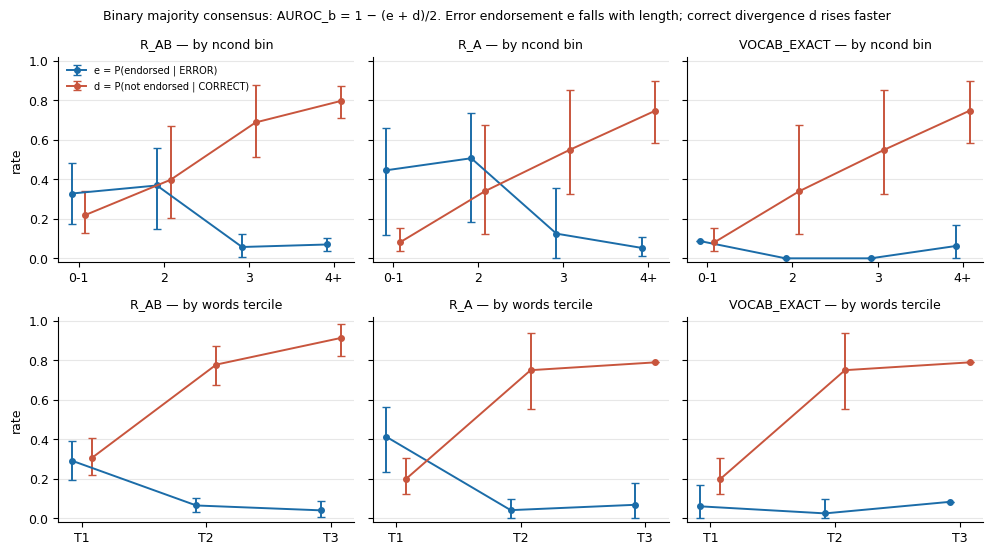

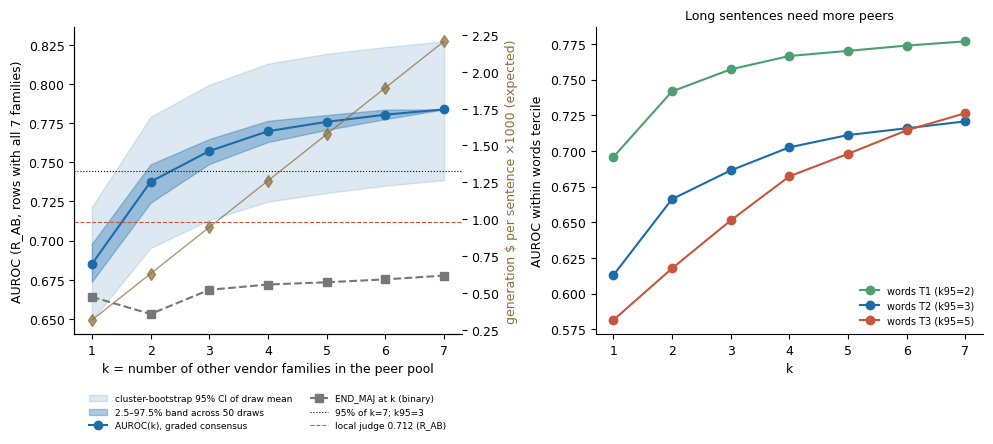

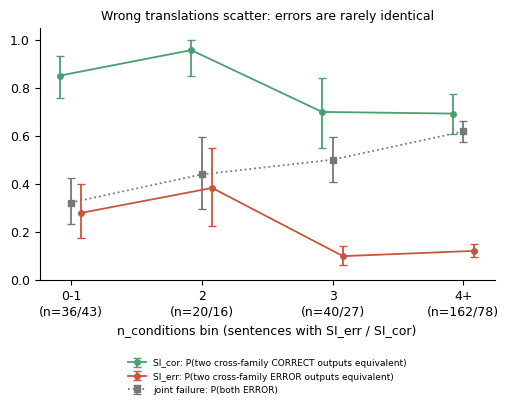

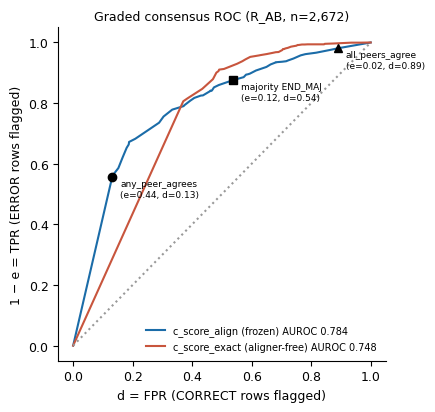

In [14]:
A_FULL = data["full_run"]["A"]
TABLES = {k: pd.DataFrame(v) for k, v in data["full_run"]["tables"].items()}


def figures(A: dict):
    # import matplotlib; matplotlib.use("Agg")  # notebook: keep the inline backend
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False})
    F = ROOT / "figures"
    F.mkdir(exist_ok=True)
    cuts = TABLES["ed_decomposition_cuts"]  # original: pd.read_csv(ROOT / "tables" / "ed_decomposition_cuts.csv", comment="#")
    C_E, C_D = "#1b6ca8", "#c8553d"
    # (1) e and d vs n_conditions bin and words tercile, per regime (END_MAJ)
    regs = ["R_AB", "R_A", "VOCAB_EXACT"]
    fig, ax = plt.subplots(2, 3, figsize=(10, 5.6), sharey=True)
    spec1 = {"type": "multi-panel errorbar", "rule": "END_MAJ", "panels": []}
    for j, rg in enumerate(regs):
        for i, (dim, order) in enumerate((("ncond_bin", ["0-1", "2", "3", "4+"]), ("words_tercile", ["T1", "T2", "T3"]))):
            sub = cuts[(cuts.regime == rg) & (cuts.dim == dim) & (cuts.rule == "MAJ")].set_index("cell").reindex(order)
            x = np.arange(len(order))
            for q, col, off in (("e", C_E, -0.08), ("d", C_D, 0.08)):
                y = sub[q].values
                lo = sub[f"{q}_ci_lo"].values.astype(float)
                hi = sub[f"{q}_ci_hi"].values.astype(float)
                err = np.array([np.where(np.isnan(lo), 0, y - lo), np.where(np.isnan(hi), 0, hi - y)])
                ax[i, j].errorbar(x + off, y, yerr=err, fmt="o-", color=col, capsize=3, lw=1.4, ms=4,
                                  label=f"{q} = {'P(endorsed | ERROR)' if q == 'e' else 'P(not endorsed | CORRECT)'}")
            ax[i, j].set_xticks(x, order)
            ax[i, j].set_title(f"{rg} — by {dim.replace('_', ' ')}", fontsize=9)
            ax[i, j].set_ylim(-0.02, 1.02)
            ax[i, j].grid(axis="y", alpha=0.3)
            spec1["panels"].append({"regime": rg, "dim": dim, "cells": order, "e": sub.e.tolist(), "d": sub.d.tolist(),
                                    "n_err": sub.n_err.tolist(), "n_cor": sub.n_cor.tolist()})
    ax[0, 0].set_ylabel("rate")
    ax[1, 0].set_ylabel("rate")
    ax[0, 0].legend(fontsize=7, frameon=False, loc="upper left")
    fig.suptitle("Binary majority consensus: AUROC_b = 1 − (e + d)/2. Error endorsement e falls with length; correct divergence d rises faster",
                 fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig1_e_d_by_complexity.{ext}", dpi=200)
    plt.show()
    plt.close(fig)
    jdump(F / "fig1_e_d_by_complexity.json", spec1)
    # (2) AUROC(k) with draw band, per tercile, $/sentence secondary axis
    r = A["M4"]["random_k_primary"]
    ks = sorted(int(k) for k in r["k"])
    m = [r["k"][str(k)]["auroc_mean"] if str(k) in r["k"] else r["k"][k]["auroc_mean"] for k in ks]
    kk = {int(k): v for k, v in r["k"].items()}
    lo = [kk[k]["auroc_ci_of_draw_mean"][0] for k in ks]
    hi = [kk[k]["auroc_ci_of_draw_mean"][1] for k in ks]
    bl = [kk[k]["draw_band"][0] for k in ks]
    bh = [kk[k]["draw_band"][1] for k in ks]
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
    ax[0].fill_between(ks, lo, hi, color="#1b6ca8", alpha=0.15, label="cluster-bootstrap 95% CI of draw mean")
    ax[0].fill_between(ks, bl, bh, color="#1b6ca8", alpha=0.35, label="2.5–97.5% band across 50 draws")
    ax[0].plot(ks, m, "o-", color="#1b6ca8", label="AUROC(k), graded consensus")
    ax[0].plot(ks, [kk[k]["endmaj_auroc_mean"] for k in ks], "s--", color="#777777", label="END_MAJ at k (binary)")
    ax[0].axhline(0.95 * kk[max(ks)]["auroc_mean"], color="k", lw=0.8, ls=":", label=f"95% of k={max(ks)}; k95={r['k95']}")
    ax[0].axhline(0.712, color="#c8553d", lw=0.8, ls="--", label="local judge 0.712 (R_AB)")
    ax[0].set_xlabel("k = number of other vendor families in the peer pool")
    ax[0].set_ylabel("AUROC (R_AB, rows with all 7 families)")
    ax2 = ax[0].twinx()
    cost = [c["usd_per_sentence_expected"] * 1000 for c in A["M4"]["cost"]["by_k"]]
    ax2.plot(ks, cost, "d-", color="#8a6d3b", alpha=0.7, lw=1)
    ax2.set_ylabel("generation $ per sentence ×1000 (expected)", color="#8a6d3b")
    ax[0].legend(fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
    for t, col in (("T1", "#4c9f70"), ("T2", "#1b6ca8"), ("T3", "#c8553d")):
        ax[1].plot(ks, [kk[k]["tercile_auroc_mean"][t] for k in ks], "o-", color=col, label=f"words {t} (k95={r['k95_tercile'][t]})")
    ax[1].set_xlabel("k")
    ax[1].set_ylabel("AUROC within words tercile")
    ax[1].legend(fontsize=7, frameon=False)
    ax[1].set_title("Long sentences need more peers", fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig2_auroc_k.{ext}", dpi=200)
    plt.show()
    plt.close(fig)
    jdump(F / "fig2_auroc_k.json", {"type": "line+band, twin axis", "k": ks, "auroc_mean": m, "ci": [lo, hi], "band": [bl, bh],
                                     "usd_per_sentence_x1000": cost, "tercile": {t: [kk[k]["tercile_auroc_mean"][t] for k in ks] for t in ("T1", "T2", "T3")},
                                     "k95": r["k95"], "k95_tercile": r["k95_tercile"]})
    # (3) SI_err vs SI_cor by n_conditions
    S = A["SCATTER"]["by_ncond_bin"]
    order = ["0-1", "2", "3", "4+"]
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    x = np.arange(len(order))
    for q, col, lab, off in (("SI_cor", "#4c9f70", "SI_cor: P(two cross-family CORRECT outputs equivalent)", -0.08),
                             ("SI_err", "#c8553d", "SI_err: P(two cross-family ERROR outputs equivalent)", 0.08),
                             ("joint_fail", "#777777", "joint failure: P(both ERROR)", 0.0)):
        y = [S[b][q]["mean"] for b in order]
        l = [S[b][q]["ci"][0] for b in order]
        h = [S[b][q]["ci"][1] for b in order]
        err = np.array([[yy - ll if ll is not None else 0 for yy, ll in zip(y, l)], [hh - yy if hh is not None else 0 for yy, hh in zip(y, h)]])
        ax.errorbar(x + off, y, yerr=err, fmt="o-" if q != "joint_fail" else "s:", color=col, capsize=3, label=lab, lw=1.3, ms=4)
    ax.set_xticks(x, [f"{b}\n(n={S[b]['SI_err']['n_sent']}/{S[b]['SI_cor']['n_sent']})" for b in order])
    ax.set_xlabel("n_conditions bin (sentences with SI_err / SI_cor)")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=1)
    ax.set_title("Wrong translations scatter: errors are rarely identical", fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig3_scatter_index.{ext}", dpi=200)
    plt.show()
    plt.close(fig)
    jdump(F / "fig3_scatter_index.json", {"type": "errorbar", "bins": order, **{q: [S[b][q] for b in order] for q in ("SI_err", "SI_cor", "joint_fail")}})
    # (4) graded ROC with named operating points
    fig, ax = plt.subplots(figsize=(4.4, 4.2))
    for nm, fn, col, key in (("c_score_align (frozen)", "graded_trace_c_score_align", "#1b6ca8", "auroc_c_score_align"),
                             ("c_score_exact (aligner-free)", "graded_trace_c_score_exact", "#c8553d", "auroc_c_score_exact")):
        tr = TABLES[fn]  # original: pd.read_csv(ROOT / "tables" / fn)
        xs = [0] + tr.d_t.tolist() + [1]
        ys = [0] + (1 - tr.e_t).tolist() + [1]
        au = A["graded_vs_binary"][key]
        ax.plot(xs, ys, "-", color=col, label=f"{nm} AUROC {au:.3f}")
    for (k, v), mk in zip(A["graded_vs_binary"]["named_points"].items(), ("o", "s", "^")):
        ax.plot(v["d"], 1 - v["e"], mk, color="k", ms=6)
        ax.annotate(f"{k.split(' (')[0]}\n(e={v['e']:.2f}, d={v['d']:.2f})", (v["d"], 1 - v["e"]), fontsize=6.5, xytext=(6, -14), textcoords="offset points")
    ax.plot([0, 1], [0, 1], ":", color="#999999")
    ax.set_xlabel("d = FPR (CORRECT rows flagged)")
    ax.set_ylabel("1 − e = TPR (ERROR rows flagged)")
    ax.legend(fontsize=7, frameon=False, loc="lower right")
    ax.set_title(f"Graded consensus ROC (R_AB, n={A['population']['consensus_scorable']:,})", fontsize=9)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(F / f"fig4_graded_roc.{ext}", dpi=200)
    plt.show()
    plt.close(fig)
    jdump(F / "fig4_graded_roc.json", {"type": "ROC", "named_points": A["graded_vs_binary"]["named_points"],
                                        "source": ["tables/graded_trace_c_score_align.csv", "tables/graded_trace_c_score_exact.csv"]})


figures(A_FULL)

## Results: demo subset vs full run

The same headline quantities recomputed on the demo subset (`A`), next to the full-run values (`eval_out.json` → `metrics_agg`).
With fewer sentences the point estimates move and the CIs widen, but the ordering should hold: graded consensus > binary END_MAJ, *e* small, *d* large.

graded-minus-binary delta CI (demo, B=2000): [0.03687900174241295, 0.10392538463265052];  NET CI: [-0.08334473541225128, 0.44900913491623246] -> BALANCED_OR_UNDETERMINED
                               quantity  demo (95 sent, 959 rows)  full run (283 sent, 2672 rows)
           AUROC c_score_align (graded)                     0.794                           0.784
     AUROC c_score_exact (aligner-free)                     0.786                           0.748
               AUROC_b END_MAJ (binary)                     0.725                           0.669
                  delta graded - binary                     0.069                           0.114
          e END_MAJ = P(endorsed|ERROR)                     0.190                           0.124
    d END_MAJ = P(not endorsed|CORRECT)                     0.360                           0.537
                       AUROC_b END_PLUR                     0.748                           0.714
                       AUROC_b END_FAM2       

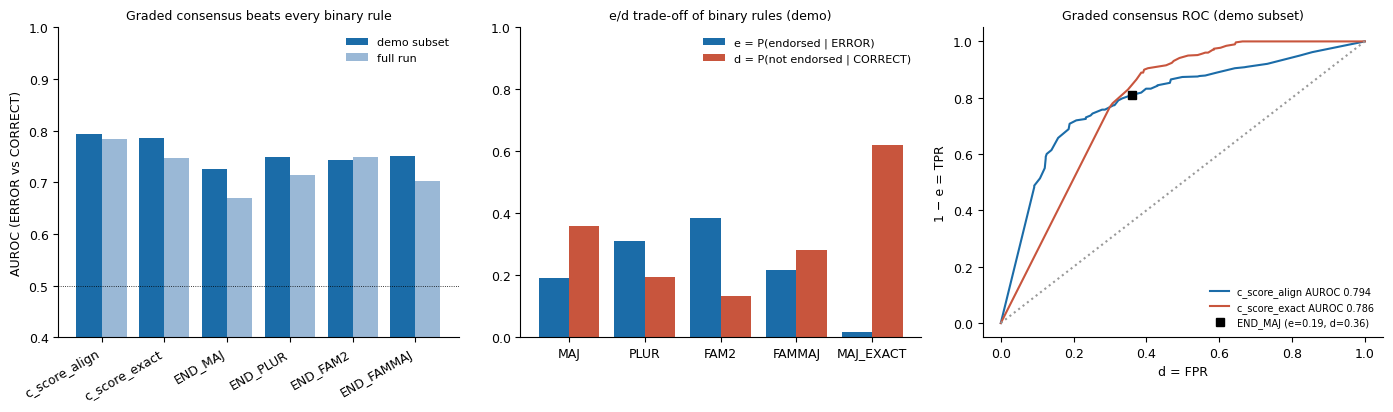

In [15]:
MA = data["full_run"]["metrics_agg"]
h = {r["rule"]: r for r in A["cuts_headline"] if r["regime"] == "R_AB"}
g = A["graded_vs_binary"]
net = A["NET"]["R_AB"]["words_T3_minus_T1"]
rows = [
    ("AUROC c_score_align (graded)", g["auroc_c_score_align"], MA["auroc_c_score_align"]),
    ("AUROC c_score_exact (aligner-free)", g["auroc_c_score_exact"], MA["auroc_c_score_exact"]),
    ("AUROC_b END_MAJ (binary)", g["auroc_b_END_MAJ"], MA["auroc_b_END_MAJ"]),
    ("delta graded - binary", g["delta_graded_minus_binary"], MA["delta_graded_minus_binary"]),
    ("e END_MAJ = P(endorsed|ERROR)", h["MAJ"]["e"], MA["e_maj_R_AB"]),
    ("d END_MAJ = P(not endorsed|CORRECT)", h["MAJ"]["d"], MA["d_maj_R_AB"]),
    ("AUROC_b END_PLUR", h["PLUR"]["auroc_b"], MA["auroc_b_plur_R_AB"]),
    ("AUROC_b END_FAM2", h["FAM2"]["auroc_b"], MA["auroc_b_fam2_R_AB"]),
    ("AUROC_b END_FAMMAJ", h["FAMMAJ"]["auroc_b"], MA["auroc_b_fammaj_R_AB"]),
    ("NET Delta(e+d) words T3-T1", net["delta_e_plus_d"], MA["net_words_T3_minus_T1"]),
    ("eqmv non-transitivity rate", A["nontransitivity"]["overall"]["rate"], MA["nontransitivity_rate"]),
    ("G2 mismatch rate (recomputed vs frozen)", A["G2"]["mismatch_rate"], MA["g2_mismatch_rate"]),
]
res = pd.DataFrame(rows, columns=["quantity", f"demo ({A['population']['n_sent']} sent, {A['population']['consensus_scorable']} rows)",
                                  f"full run ({A_FULL['population']['n_sent']} sent, {A_FULL['population']['consensus_scorable']} rows)"])
print(f"graded-minus-binary delta CI (demo, B={B_BOOT}): {g['delta_ci']};  NET CI: {net['ci']} -> {net['verdict']}")
print(res.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
# (a) AUROC of every score/rule, demo vs full
lab = ["c_score_align", "c_score_exact", "END_MAJ", "END_PLUR", "END_FAM2", "END_FAMMAJ"]
dv = [g["auroc_c_score_align"], g["auroc_c_score_exact"], h["MAJ"]["auroc_b"], h["PLUR"]["auroc_b"], h["FAM2"]["auroc_b"], h["FAMMAJ"]["auroc_b"]]
fv = [MA["auroc_c_score_align"], MA["auroc_c_score_exact"], MA["auroc_b_maj_R_AB"], MA["auroc_b_plur_R_AB"], MA["auroc_b_fam2_R_AB"], MA["auroc_b_fammaj_R_AB"]]
x = np.arange(len(lab))
ax[0].bar(x - 0.2, dv, 0.4, label="demo subset", color="#1b6ca8")
ax[0].bar(x + 0.2, fv, 0.4, label="full run", color="#9ab8d6")
ax[0].axhline(0.5, color="k", lw=0.6, ls=":")
ax[0].set_xticks(x, lab, rotation=30, ha="right")
ax[0].set_ylim(0.4, 1)
ax[0].set_ylabel("AUROC (ERROR vs CORRECT)")
ax[0].set_title("Graded consensus beats every binary rule", fontsize=9)
ax[0].legend(frameon=False, fontsize=8)
# (b) e and d per binary rule (demo): AUROC_b = 1 - (e+d)/2
rl = ["MAJ", "PLUR", "FAM2", "FAMMAJ", "MAJ_EXACT"]
ax[1].bar(np.arange(5) - 0.2, [h[r]["e"] for r in rl], 0.4, color="#1b6ca8", label="e = P(endorsed | ERROR)")
ax[1].bar(np.arange(5) + 0.2, [h[r]["d"] for r in rl], 0.4, color="#c8553d", label="d = P(not endorsed | CORRECT)")
ax[1].set_xticks(np.arange(5), rl)
ax[1].set_ylim(0, 1)
ax[1].set_title("e/d trade-off of binary rules (demo)", fontsize=9)
ax[1].legend(frameon=False, fontsize=8)
# (c) graded ROC on the demo subset
for tr, nm, col, au in ((TRACE_ALIGN, "c_score_align", "#1b6ca8", g["auroc_c_score_align"]),
                        (TRACE_EXACT, "c_score_exact", "#c8553d", g["auroc_c_score_exact"])):
    ax[2].plot([0] + tr.d_t.tolist() + [1], [0] + (1 - tr.e_t).tolist() + [1], "-", color=col, label=f"{nm} AUROC {au:.3f}")
v = g["named_points"]["majority END_MAJ (c<0.5)"]
ax[2].plot(v["d"], 1 - v["e"], "ks", ms=6, label=f"END_MAJ (e={v['e']:.2f}, d={v['d']:.2f})")
ax[2].plot([0, 1], [0, 1], ":", color="#999999")
ax[2].set_xlabel("d = FPR")
ax[2].set_ylabel("1 − e = TPR")
ax[2].set_title("Graded consensus ROC (demo subset)", fontsize=9)
ax[2].legend(frameon=False, fontsize=7, loc="lower right")
fig.tight_layout()
plt.show()